In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
try:
    df = pd.read_csv('dataset/advertising.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Could not find 'dataset/advertising.csv'. Please check the path.")


Dataset loaded successfully.


In [2]:
print(f"Shape of dataset: {df.shape}\n")

print("--- Columns ---")
print(df.columns.tolist(), "\n")

print("--- Data Types ---")
print(df.dtypes, "\n")

print("--- Missing Values ---")
print(df.isnull().sum(), "\n")

print(f"Duplicate Rows: {df.duplicated().sum()}\n")

print("--- First 5 Rows ---")
display(df.head())

print("--- Summary Statistics ---")
display(df.describe())


Shape of dataset: (200, 4)

--- Columns ---
['TV', 'Radio', 'Newspaper', 'Sales'] 

--- Data Types ---
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object 

--- Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64 

Duplicate Rows: 0

--- First 5 Rows ---


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


--- Summary Statistics ---


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Summary of Initial Inspection
Based on the output, the dataset contains **200 rows** and **4 columns** (`TV`, `Radio`, `Newspaper`, and our target `Sales`). All variables are numeric (floating-point numbers), which is ideal for modeling. There are **no missing values** and **no duplicate rows**, meaning the dataset is remarkably clean out of the box. 

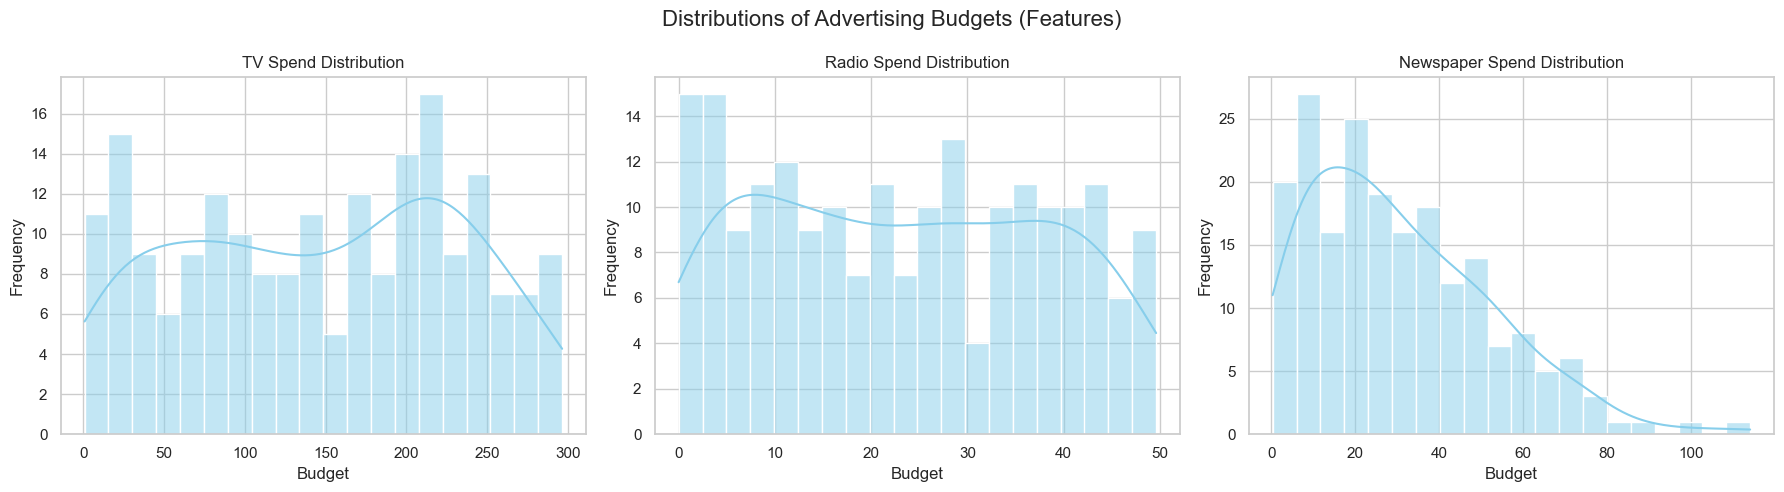

In [3]:
# Univariate Analysis of the Predictors
features = ['TV', 'Radio', 'Newspaper']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Advertising Budgets (Features)', fontsize=16)

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{feature} Spend Distribution')
    axes[i].set_xlabel('Budget')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


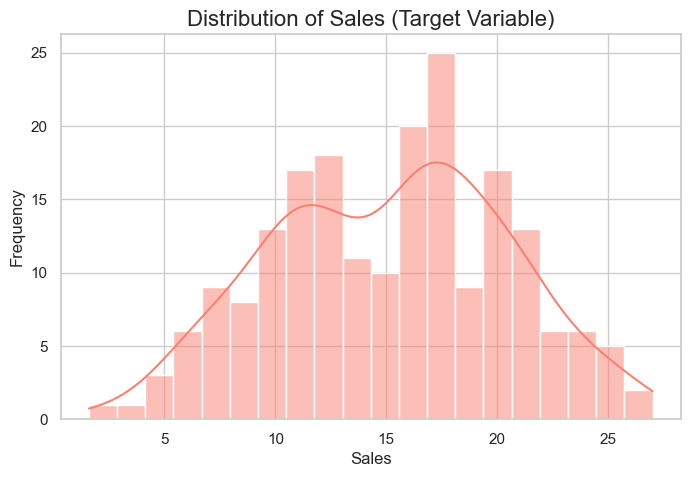

--- Skewness Values ---
TV          -0.069853
Radio        0.094175
Newspaper    0.894720
Sales       -0.073739
dtype: float64


In [4]:
# Distribution of the Target Variable (Sales)
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Sales (Target Variable)', fontsize=16)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Check skewness
print("--- Skewness Values ---")
print(df.skew())


## Summary of Distribution & Skewness
While `TV` and `Radio` budgets are fairly uniformly distributed and don't show concerning skewness, **`Newspaper`** is right-skewed (skew > 0.89), indicating that most advertising campaigns allocate a smaller budget here, with a few high-spending outliers. Crucially, the **`Sales`** target variable appears quite normally distributed, which provides a great foundation for standard linear regression without needing immediate log transformations.

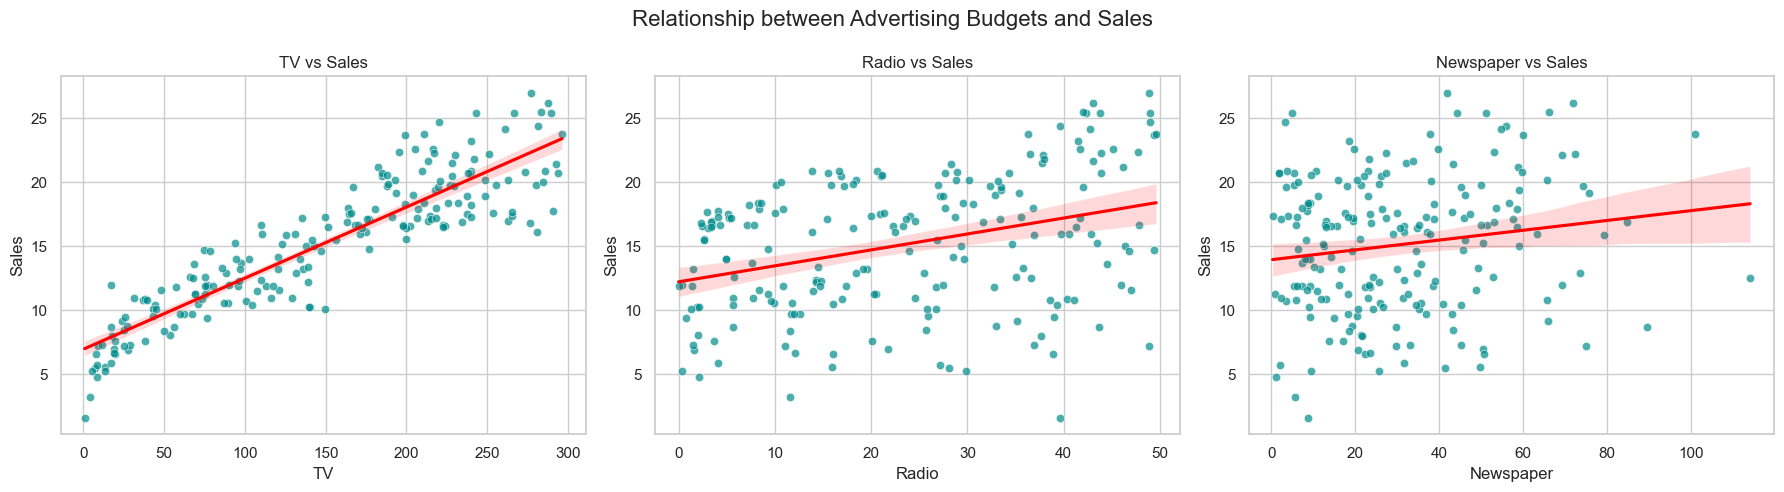

In [5]:
# Scatter plots: Feature vs. Target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relationship between Advertising Budgets and Sales', fontsize=16)

for i, feature in enumerate(features):
    sns.scatterplot(x=df[feature], y=df['Sales'], ax=axes[i], alpha=0.7, color='darkcyan')
    sns.regplot(x=df[feature], y=df['Sales'], ax=axes[i], scatter=False, color='red') # adds a trendline
    axes[i].set_title(f'{feature} vs Sales')

plt.tight_layout()
plt.show()


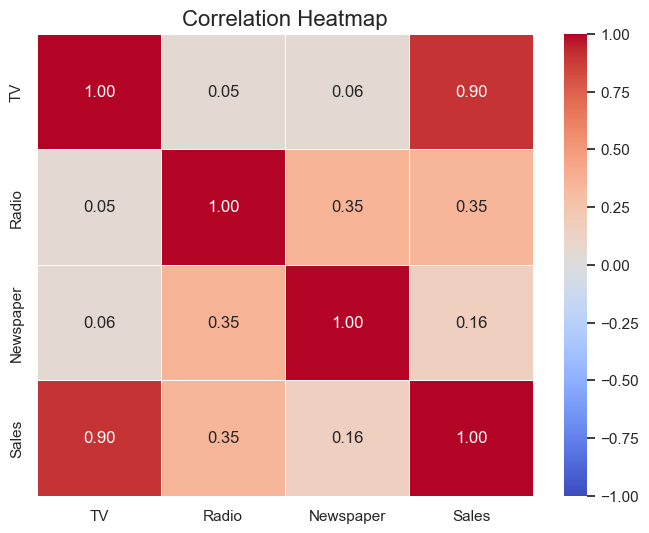

In [6]:
# Correlation Matrix and Heatmap
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()


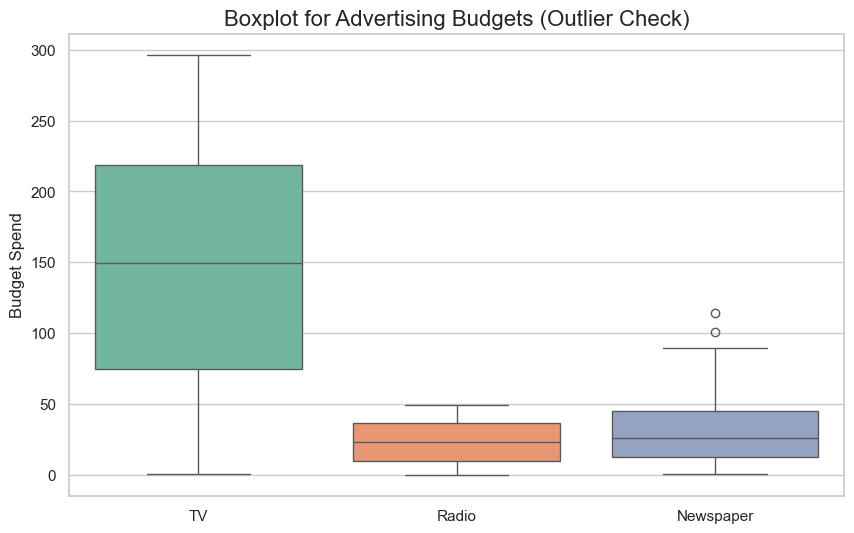

In [7]:
# Boxplots for Outlier Detection
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[features], palette='Set2')
plt.title('Boxplot for Advertising Budgets (Outlier Check)', fontsize=16)
plt.ylabel('Budget Spend')
plt.show()


## Summary of Relationships & Outliers
Our visual and statistical analysis reveals that **`TV`** advertising has the strongest positive correlation with `Sales` (around 0.78), followed by **`Radio`**. Conversely, **`Newspaper`** has a very weak correlation with sales. The boxplots showed two minor outliers on the high end of `Newspaper` spend. Because these are realistic budget numbers and the skewness is manageable, we will leave the data strictly untouched. 

Since the data is clean and the relationships are highly linear, we are ready for regression modeling. Let's begin by defining our target and features, and splitting the data.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop('Sales', axis=1)
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set : X_test={X_test.shape}, y_test={y_test.shape}\n")


Training set: X_train=(160, 3), y_train=(160,)
Testing set : X_test=(40, 3), y_test=(40,)



### Baseline Models: Linear Regression, Ridge, and Lasso
We will train standard OLS Linear Regression alongside two regularized versions: Ridge (L2 penalty) and Lasso (L1 penalty). We will evaluate their Mean Squared Error (MSE) and $R^2$ scores, and analyze the feature coefficients to verify which advertising channels matter most.


In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1)
}

results = []
coefficients = pd.DataFrame(index=X.columns)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "MSE": mse, "R2 Score": r2})
    coefficients[name] = model.coef_

results_df = pd.DataFrame(results).set_index("Model")
print("--- Model Performance ---")
display(results_df)

print("\n--- Feature Coefficients ---")
display(coefficients)


--- Model Performance ---


,MSE,R2 Score
Model,,
Linear Regression,2.907757,0.905901
Ridge (L2),2.907796,0.905900
Lasso (L1),2.909322,0.905851



--- Feature Coefficients ---


,Linear Regression,Ridge (L2),Lasso (L1)
TV,0.054509,0.054509,0.054499
Radio,0.100945,0.100942,0.100562
Newspaper,0.004337,0.004338,0.004202
